# **Echocardiogram / ECG Classification — CNN vs. Hybrid CNN-Transformer**

Dataset: [Echocardiogram(EKG) dataset](https://www.kaggle.com/datasets/kriegmann/echocardiogramekg-dataset)
— 4 cardiac condition classes: **Angina Disease, Cardio Vascular Disease, Coronary Artery
Disease, Hypotension Disease**, graded by cardiologists at the Marian Cardiac Centre, Poland.

## Setup & Data Acquisition

### Download dataset from Kaggle

In [1]:
from google.colab import files
files.upload()  # upload your kaggle.json here

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"efficient8","key":"0e26061c5d5cf73b850e01f7c6575016"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle

In [3]:
!kaggle datasets download -d kriegmann/echocardiogramekg-dataset
!unzip -q -o echocardiogramekg-dataset.zip -d echo_ekg_data

Dataset URL: https://www.kaggle.com/datasets/kriegmann/echocardiogramekg-dataset
License(s): unknown
100% 74.1M/74.1M [00:00<00:00, 140MB/s]



### Imports

In [4]:
import os
import math
import random
import shutil
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow.keras import layers

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, DenseNet121, MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_score, recall_score, f1_score, accuracy_score
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.facecolor'] = 'white'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

### Configuration

In [5]:
RAW_ROOT   = "echo_ekg_data"   # raw extracted zip contents
SPLIT_ROOT = "dataset"         # our own train/val/test folder structure goes here

image_size = (224, 224)
batch_size = 32
epochs     = 25

## **Data Discovery, Flattening & Train/Val/Test Split**

### Flatten the nested folders

In [6]:
top_level_dirs = [d for d in os.listdir(RAW_ROOT) if os.path.isdir(os.path.join(RAW_ROOT, d))]
print(f"Initial top-level directories in {RAW_ROOT}:\n{top_level_dirs}\n")

for disease_root_folder in top_level_dirs:
    full_disease_root_path = os.path.join(RAW_ROOT, disease_root_folder)

    sub_items = os.listdir(full_disease_root_path)
    sub_dirs = [item for item in sub_items if os.path.isdir(os.path.join(full_disease_root_path, item))]

    # Exactly one nested sub-folder -> move its contents up, then remove it
    if len(sub_dirs) == 1:
        nested_sub_folder_path = os.path.join(full_disease_root_path, sub_dirs[0])
        print(f"Flattening: {nested_sub_folder_path}")
        for item in os.listdir(nested_sub_folder_path):
            shutil.move(
                os.path.join(nested_sub_folder_path, item),
                os.path.join(full_disease_root_path, item)
            )
        os.rmdir(nested_sub_folder_path)

# Strip trailing underscores from folder names
top_level_dirs = [d for d in os.listdir(RAW_ROOT) if os.path.isdir(os.path.join(RAW_ROOT, d))]
for folder_name in top_level_dirs:
    if folder_name.endswith('_'):
        old_path = os.path.join(RAW_ROOT, folder_name)
        new_path = os.path.join(RAW_ROOT, folder_name.rstrip('_'))
        shutil.move(old_path, new_path)
        print(f"Renamed '{folder_name}' -> '{folder_name.rstrip(chr(39))}'")

class_names = sorted([d for d in os.listdir(RAW_ROOT) if os.path.isdir(os.path.join(RAW_ROOT, d))])
num_classes = len(class_names)
print(f"\nFinal classes ({num_classes}): {class_names}")

Initial top-level directories in echo_ekg_data:
['hypotension_disease_', 'angina_disease', 'coronary_artery_disease', 'cardio_vascular_disease_']

Flattening: echo_ekg_data/hypotension_disease_/hypotension_disease_
Flattening: echo_ekg_data/angina_disease/angina_disease
Flattening: echo_ekg_data/coronary_artery_disease/coronary_artery_disease
Flattening: echo_ekg_data/cardio_vascular_disease_/cardio_disease_
Renamed 'hypotension_disease_' -> 'hypotension_disease_'
Renamed 'cardio_vascular_disease_' -> 'cardio_vascular_disease_'

Final classes (4): ['angina_disease', 'cardio_vascular_disease', 'coronary_artery_disease', 'hypotension_disease']


### Split into `dataset/train | val | test / <class>/`

In [ ]:
# angina_images = [i for i in os.listdir('echo_ekg_data/angina_disease')]
# angina_images

In [11]:
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15
IMG_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.jpe', '.bmp', '.tif', '.tiff')


# Start clean
if os.path.exists(SPLIT_ROOT):
    shutil.rmtree(SPLIT_ROOT)
for split in ('train', 'val', 'test'):
    for cname in class_names:
        os.makedirs(os.path.join(SPLIT_ROOT, split, cname), exist_ok=True)

split_counts = {'train': {}, 'val': {}, 'test': {}}

for cname in class_names:
    class_dir = os.path.join(RAW_ROOT, cname)
    images = [f for f in os.listdir(class_dir) if f.lower().endswith(IMG_EXTENSIONS)]
    random.shuffle(images)

    n_total = len(images)
    n_train = int(n_total * TRAIN_RATIO)
    n_val   = int(n_total * VAL_RATIO)

    splits = {
        'train': images[:n_train],
        'val':   images[n_train:n_train + n_val],
        'test':  images[n_train + n_val:],
    }

    for split_name, files in splits.items():
        for fname in files:
            shutil.copy2(
                os.path.join(class_dir, fname),
                os.path.join(SPLIT_ROOT, split_name, cname, fname)
            )
        split_counts[split_name][cname] = len(files)

print("Split summary:")
for split_name in ('train', 'val', 'test'):
    total = sum(split_counts[split_name].values())
    print(f"  {split_name}: {split_counts[split_name]}  (total={total})")

train_path = os.path.join(SPLIT_ROOT, "train")
val_path   = os.path.join(SPLIT_ROOT, "val")
test_path  = os.path.join(SPLIT_ROOT, "test")

Split summary:
  train: {'angina_disease': 424, 'cardio_vascular_disease': 419, 'coronary_artery_disease': 419, 'hypotension_disease': 420}  (total=1682)
  val: {'angina_disease': 90, 'cardio_vascular_disease': 89, 'coronary_artery_disease': 89, 'hypotension_disease': 90}  (total=358)
  test: {'angina_disease': 92, 'cardio_vascular_disease': 91, 'coronary_artery_disease': 91, 'hypotension_disease': 91}  (total=365)


## **Exploratory Data Analysis (EDA)**

### Helper — count images per class in every split

In [12]:
def count_images(directory):
    return {c: len(os.listdir(os.path.join(directory, c))) for c in class_names}

train_counts = count_images(train_path)
val_counts   = count_images(val_path)
test_counts  = count_images(test_path)

counts_df = pd.DataFrame({'Train': train_counts, 'Val': val_counts, 'Test': test_counts}).reindex(class_names)
counts_df

,Train,Val,Test
angina_disease,424,90,92
cardio_vascular_disease,419,89,91
coronary_artery_disease,419,89,91
hypotension_disease,420,90,91


### Class distribution across Train / Val / Test splits

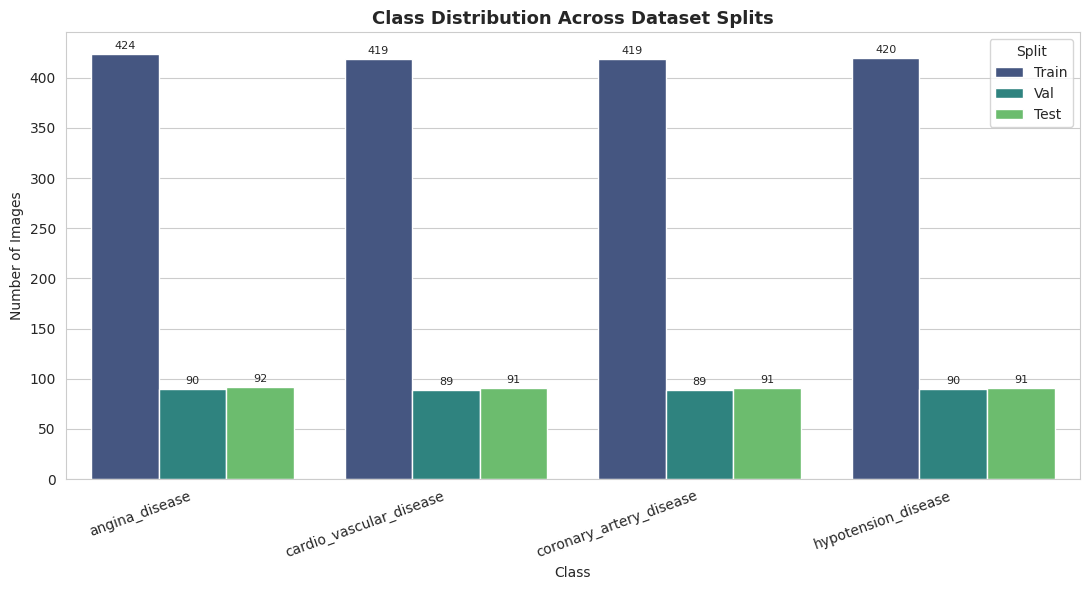

In [13]:
split_plot_df = counts_df.reset_index().melt(id_vars='index', var_name='Split', value_name='Count')
split_plot_df.rename(columns={'index': 'Class'}, inplace=True)

plt.figure(figsize=(11, 6))
ax = sns.barplot(data=split_plot_df, x='Class', y='Count', hue='Split', palette='viridis')
for container in ax.containers:
    ax.bar_label(container, fontsize=8, padding=2)
plt.title('Class Distribution Across Dataset Splits', fontsize=13, fontweight='bold')
plt.xlabel('Class'); plt.ylabel('Number of Images')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Split')
plt.tight_layout()
plt.show()

### Overall class proportions

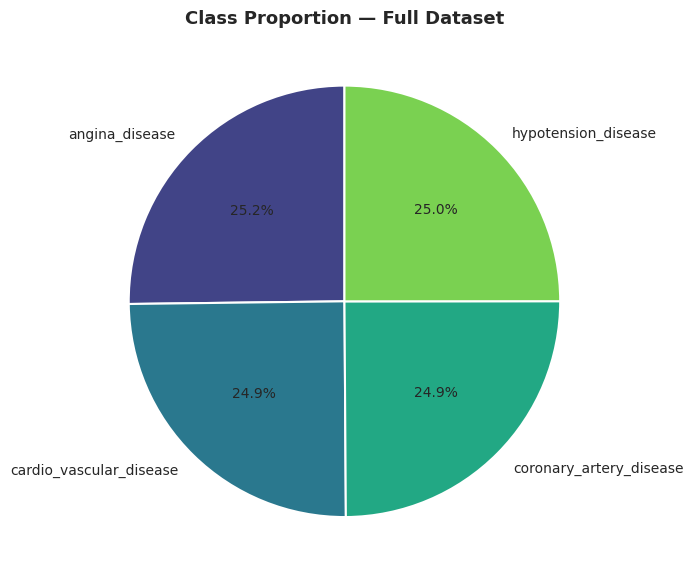

In [14]:
overall_counts = (counts_df['Train'] + counts_df['Val'] + counts_df['Test'])

plt.figure(figsize=(7, 7))
colors = sns.color_palette('viridis', num_classes)
plt.pie(
    overall_counts.values, labels=overall_counts.index, autopct='%1.1f%%',
    startangle=90, colors=colors, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
plt.title('Class Proportion — Full Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Sample images per class

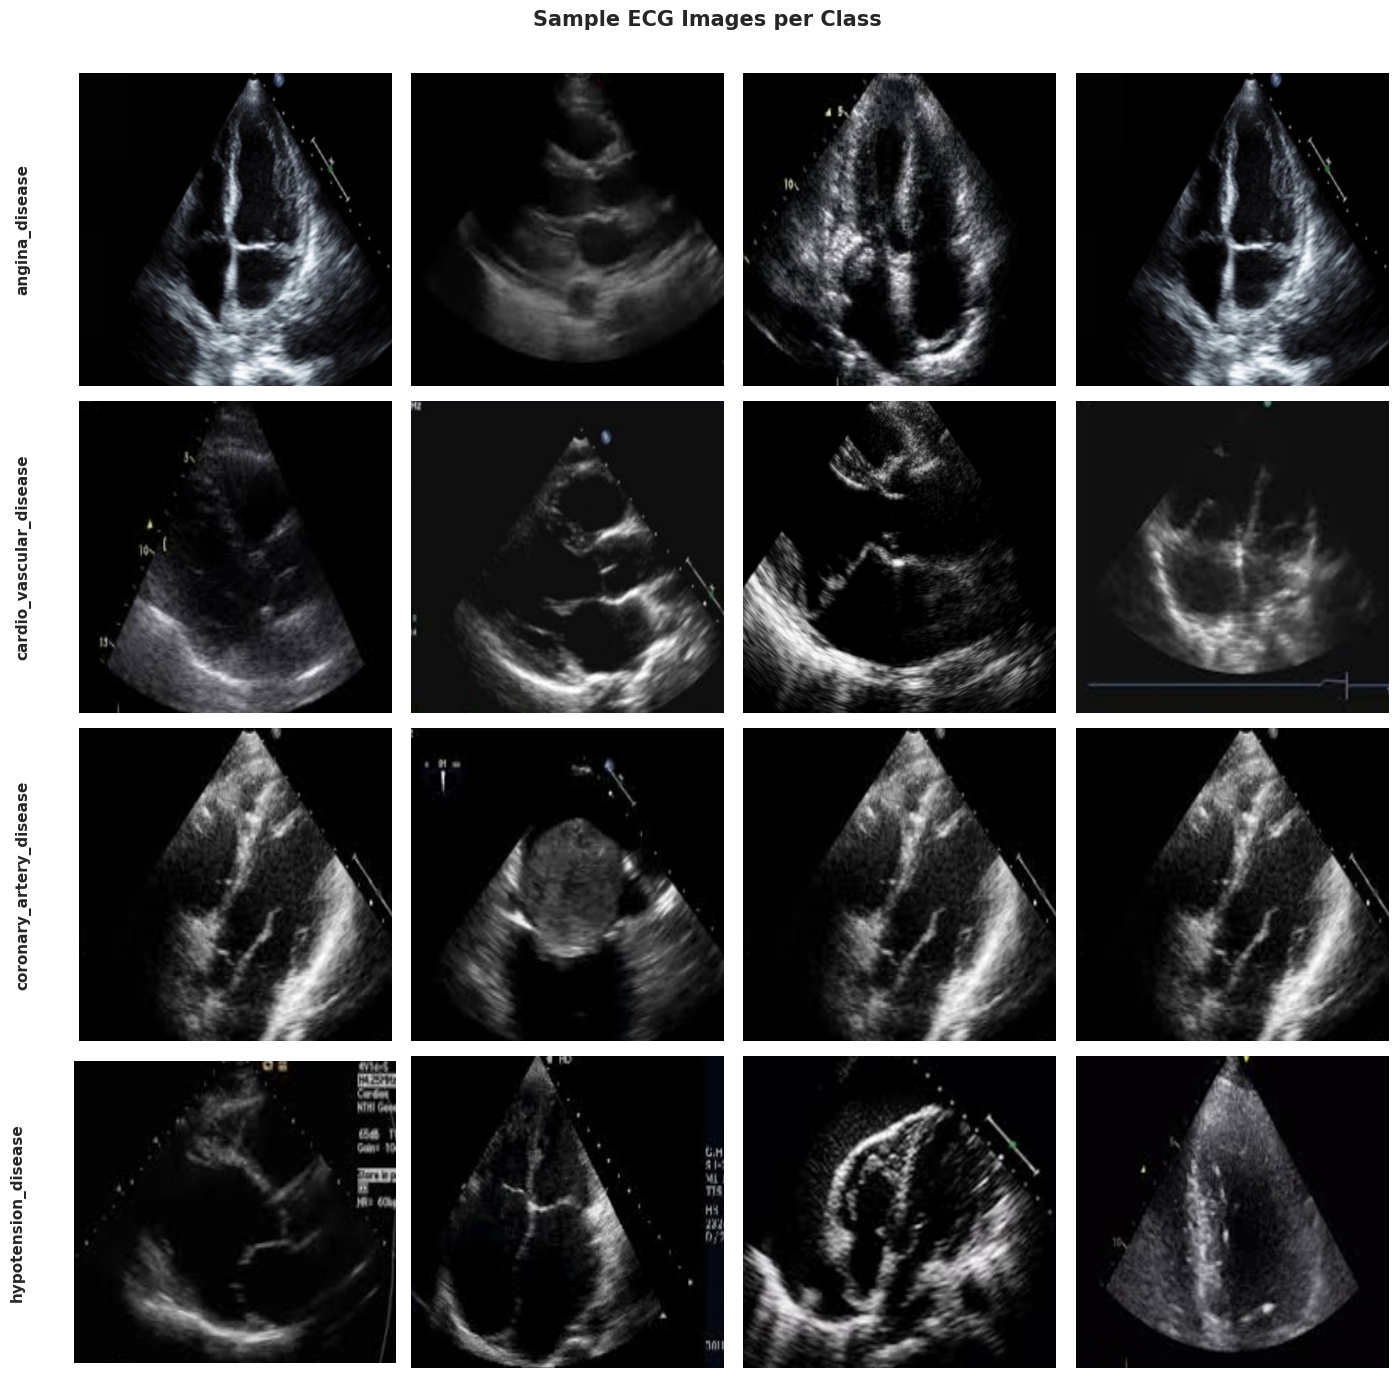

In [15]:
fig, axes = plt.subplots(num_classes, 4, figsize=(14, 3.4 * num_classes))
fig.suptitle('Sample ECG Images per Class', fontsize=15, fontweight='bold', y=1.01)

for row, cname in enumerate(class_names):
    class_dir = os.path.join(train_path, cname)
    files_in_class = os.listdir(class_dir)
    sample_files = random.sample(files_in_class, min(4, len(files_in_class)))

    for col in range(4):
        ax = axes[row, col]
        if col < len(sample_files):
            img = cv2.cvtColor(cv2.imread(os.path.join(class_dir, sample_files[col])), cv2.COLOR_BGR2RGB)
            ax.imshow(img)
        ax.axis('off')
    axes[row, 0].text(-0.15, 0.5, cname, transform=axes[row, 0].transAxes,
                       fontsize=11, fontweight='bold', va='center', ha='right', rotation=90)

plt.tight_layout()
plt.show()

### Pixel intensity distribution by class

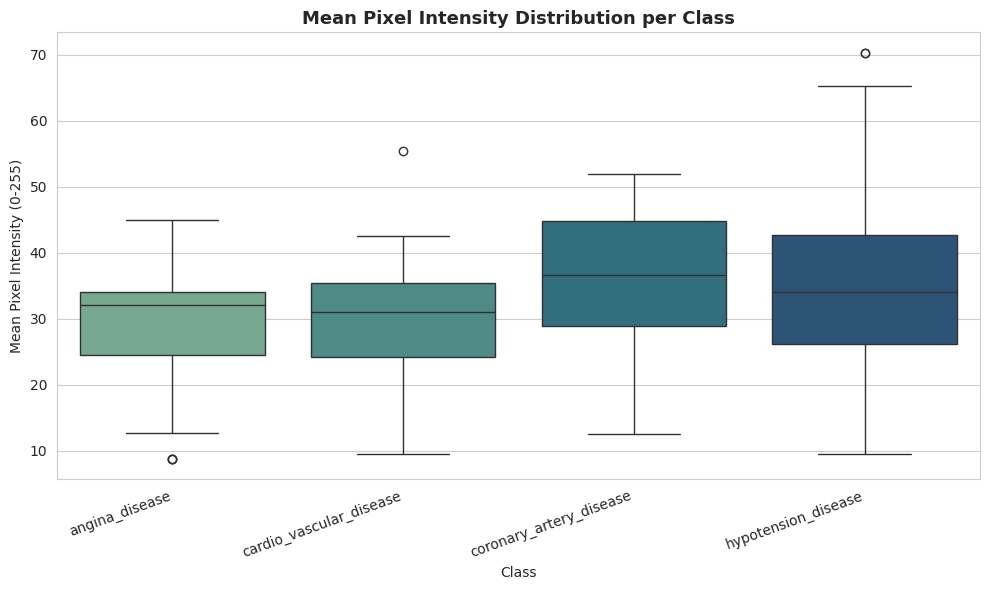

In [16]:
intensity_records = []
for cname in class_names:
    class_dir = os.path.join(train_path, cname)
    files_in_class = os.listdir(class_dir)
    for fname in random.sample(files_in_class, min(60, len(files_in_class))):
        img = cv2.imread(os.path.join(class_dir, fname), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            intensity_records.append({'class': cname, 'mean_intensity': img.mean()})

intensity_df = pd.DataFrame(intensity_records)

plt.figure(figsize=(10, 6))
sns.boxplot(data=intensity_df, x='class', y='mean_intensity', hue='class', palette='crest', legend=False)
plt.title('Mean Pixel Intensity Distribution per Class', fontsize=13, fontweight='bold')
plt.xlabel('Class'); plt.ylabel('Mean Pixel Intensity (0-255)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

### Image dimension & aspect ratio distribution

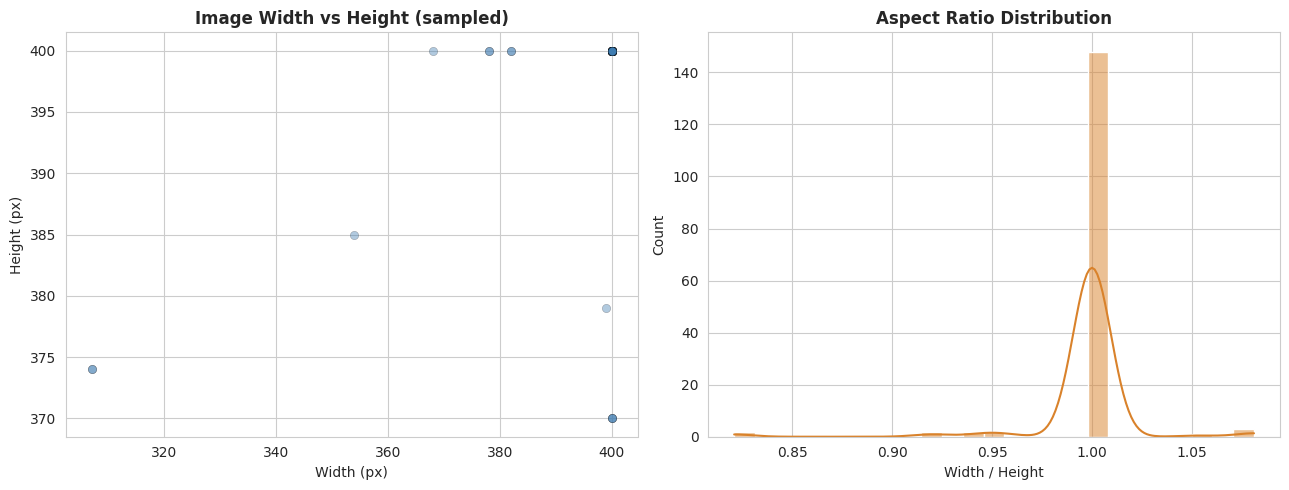

In [17]:
dim_records = []
for cname in class_names:
    class_dir = os.path.join(train_path, cname)
    files_in_class = os.listdir(class_dir)
    for fname in random.sample(files_in_class, min(40, len(files_in_class))):
        img = cv2.imread(os.path.join(class_dir, fname))
        if img is not None:
            h, w = img.shape[:2]
            dim_records.append({'class': cname, 'width': w, 'height': h, 'aspect_ratio': w / h})

dims_df = pd.DataFrame(dim_records)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(dims_df['width'], dims_df['height'], alpha=0.4, c='#3E7CB1', edgecolor='k', linewidth=0.3)
axes[0].set_title('Image Width vs Height (sampled)', fontweight='bold')
axes[0].set_xlabel('Width (px)'); axes[0].set_ylabel('Height (px)')

sns.histplot(dims_df['aspect_ratio'], bins=25, kde=True, ax=axes[1], color='#D9822B')
axes[1].set_title('Aspect Ratio Distribution', fontweight='bold')
axes[1].set_xlabel('Width / Height')

plt.tight_layout()
plt.show()

### Edge detection (QRS pattern view)

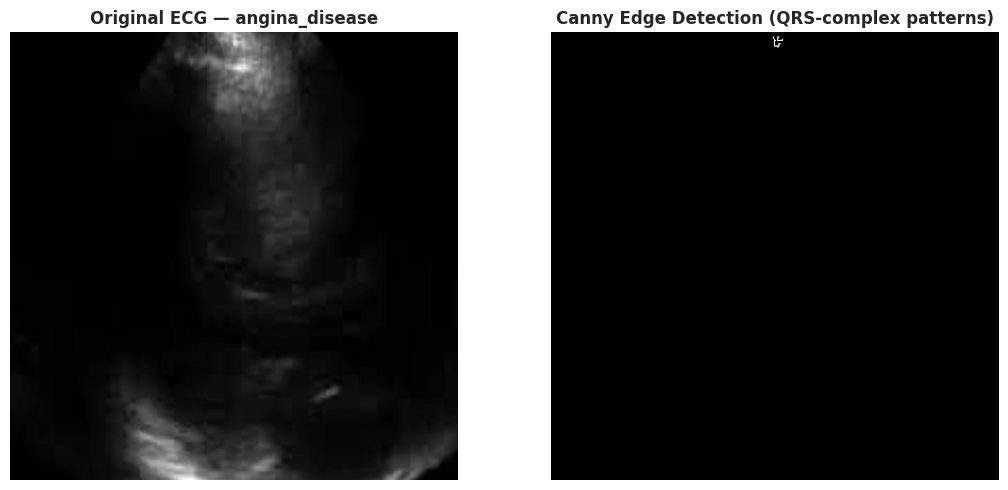

In [18]:
sample_class_dir = os.path.join(train_path, class_names[0])
sample_file = os.listdir(sample_class_dir)[0]
sample_gray = cv2.imread(os.path.join(sample_class_dir, sample_file), cv2.IMREAD_GRAYSCALE)
edges = cv2.Canny(sample_gray, 100, 200)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(sample_gray, cmap='gray')
axes[0].set_title(f'Original ECG — {class_names[0]}', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(edges, cmap='gray')
axes[1].set_title('Canny Edge Detection (QRS-complex patterns)', fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## **Data Generators & Class Weights**

In [19]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path, target_size=image_size, batch_size=batch_size,
    class_mode='categorical', classes=class_names, shuffle=True, seed=SEED
)

val_generator = val_test_datagen.flow_from_directory(
    val_path, target_size=image_size, batch_size=batch_size,
    class_mode='categorical', classes=class_names, shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_path, target_size=image_size, batch_size=batch_size,
    class_mode='categorical', classes=class_names, shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 290 images belonging to 4 classes.
Found 63 images belonging to 4 classes.
Found 51 images belonging to 4 classes.
Class indices: {'angina_disease': 0, 'cardio_vascular_disease': 1, 'coronary_artery_disease': 2, 'hypotension_disease': 3}


In [20]:
counts = Counter(train_generator.classes)
counts_arr = np.array(list(counts.values()))
imbalance_ratio = counts_arr.max() / counts_arr.min()
print(f"Imbalance Ratio (max/min class count): {imbalance_ratio:.2f}")

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Imbalance Ratio (max/min class count): 2.43
Class Weights: {0: np.float64(0.6092436974789915), 1: np.float64(1.2719298245614035), 2: np.float64(1.1153846153846154), 3: np.float64(1.4795918367346939)}
